# **ML Features Usage in IDEs**

## Import Packages and Dataset

In [75]:
import pandas as pd
import numpy as np
import scipy.stats as st
from scipy.stats import pearsonr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from pandasql import sqldf

In [76]:
df = pd.read_csv("da_internship_task_dataset.csv")

### Preprocess dataset: convert day_id column to datatime type, get month column for data analysis

In [77]:
df = df.dropna()
df['day_id'] = pd.to_datetime(df['day_id'])
df['month'] = df['day_id'].dt.strftime('%m')

### Disclaimer for Parts 1, 2 & 3

To keep the analysis organized and readable, for Parts 1, 2, and 3, **“user activity” or “user usage”** refers **literally to the number of registered activity logs** in the dataset.  

**Request counts** have not been analyzed in these parts, as they involve additional nuances and will be addressed separately in part 4 of the notebook.

*Note: In these parts, all statistics are **normalized** to remove the baseline effect of license volume. Our goal is to understand how each variable type (model or feature) contributes to user activity, without being confounded by differences in license counts.*

Notebook structure:
- Part 1 to 4: include codes, statistics, in combination with visualization.
      - Underneath each block of code and outcome, there would be interpretation
- Recommendations.

## Part 1: Basic Grouping and Descriptive Statistics

In [78]:
print(f'Number of unique users across this time period {len(df['uuid'].unique())}\n')
user_license_types = df.groupby('uuid')['license'].unique()
user_license_types = user_license_types.apply(lambda x: tuple(sorted(x)) if hasattr(x, '__iter__') else (x,))
types_counts = user_license_types.value_counts()

# 
print(types_counts.head(4))

Number of unique users across this time period 1866

license
(Basic,)         675
(Standard,)      666
(Premium,)       234
(Enterprise,)    234
Name: count, dtype: int64


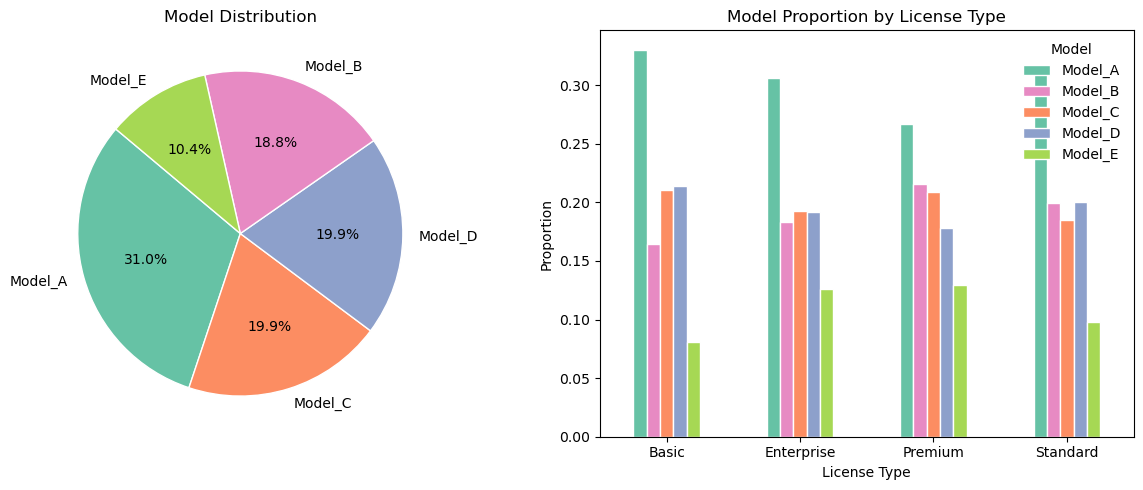

In [79]:
# Fundamental descriptive statistics (activity count by model, model grouped by license)
model_descriptives = df['model'].value_counts()
license_model_descriptives = df.groupby('license')['model'].value_counts(normalize=True)
license_model_descriptives = license_model_descriptives.unstack('model')

palette = sns.color_palette("Set2", n_colors=len(model_descriptives))

model_names = list(model_descriptives.index)
color_map = {model: palette[i % len(palette)] for i, model in enumerate(model_names)}
bar_colors = [color_map[col] for col in license_model_descriptives.columns]

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].pie(
    model_descriptives.values,
    labels=model_names,
    autopct='%1.1f%%',
    startangle=140,
    colors=[color_map[m] for m in model_names],
    wedgeprops={'edgecolor': 'white', 'linewidth': 1})

axes[0].set_title('Model Distribution')

license_model_descriptives.plot(
    kind='bar',
    ax=axes[1],
    legend=True,
    color=bar_colors,
    edgecolor='white')

axes[1].set_title('Model Proportion by License Type')
axes[1].set_ylabel('Proportion')
axes[1].set_xlabel('License Type')
axes[1].tick_params(axis='x', rotation=0)
handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend(handles, labels, title='Model', frameon=False)

plt.tight_layout()
plt.show()

When grouped by model, the highest share of activity logs is associated with ***model A*** (**31%**), followed by ***models D and C***, which each account for **19.9%** of the logs.

Looking closer at this distribution by license type, the overall ranking remains the same, except for premium license users, who use model B more frequently than models C and D.

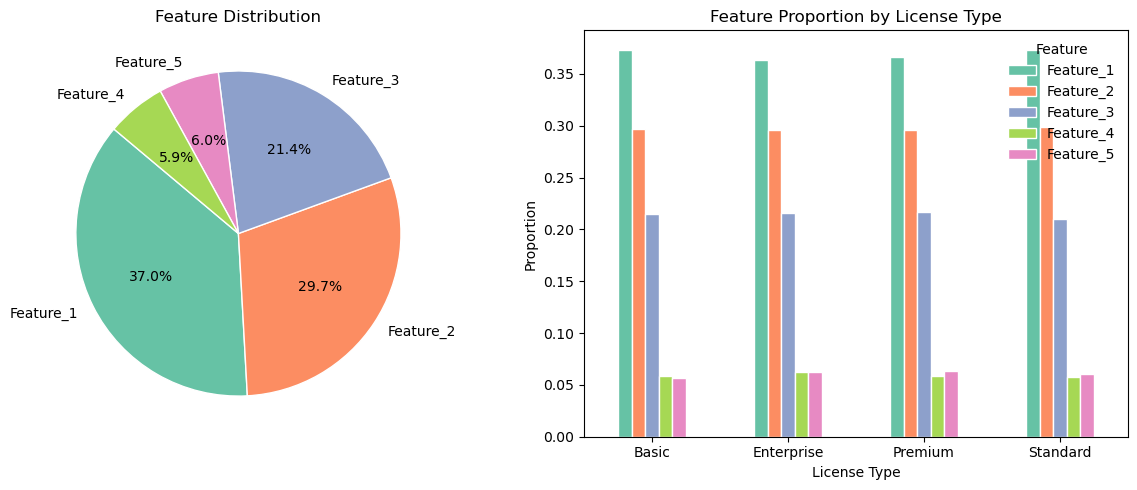

In [80]:
# Descriptive statistics (Feature), partitioned by License
feature_descriptives = df['feature'].value_counts()
license_feature_descriptives = df.groupby('license')['feature'].value_counts(normalize=True)
license_feature_descriptives = license_feature_descriptives.unstack('feature')
feature_names = feature_descriptives.index
color_map = {feature: palette[i % len(palette)] for i, feature in enumerate(feature_names)}
bar_colors = [color_map[col] for col in license_feature_descriptives.columns]

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].pie(
    feature_descriptives.values,
    labels=feature_names,
    autopct='%1.1f%%',
    startangle=140,
    colors=[color_map[m] for m in feature_names],
    wedgeprops={'edgecolor': 'white', 'linewidth': 1})
axes[0].set_title('Feature Distribution')

license_feature_descriptives.plot(
    kind='bar',
    ax=axes[1],
    legend=True,
    color=bar_colors,
    edgecolor='white')

axes[1].set_title('Feature Proportion by License Type')
axes[1].set_ylabel('Proportion')
axes[1].set_xlabel('License Type')
axes[1].tick_params(axis='x', rotation=0)

handles, labels = axes[1].get_legend_handles_labels()
axes[1].legend(handles, labels, title='Feature', frameon=False)

plt.tight_layout()
plt.show()

***Feature 1*** appears to dominate across all features, accounting for **37%** of user activity logs, followed by Feature **2**, which accounts for **29.7%**. This ranking is consistent across all license types, as the same trend is observed regardless of plan.


### General Conclusion 1

The number of unique users during the 3-month period is *1866*. The majority of them hold ***Basic*** and ***Standard*** licenses, with 675 and 666 users respectively. The total number of ***Enterprise*** and ***Premium*** users makes up only **25%** of all users (468 users).

In summary, ***model A*** and ***feature 1*** appear to be the most common across all license types, each accounting for more than **30%** of their respective category.  

However, this observation should not be considered conclusive, as there is still much information to be analyzed.


## Part 2: Aggregation across Months

*In this part 2, user activity (here, we take into account literally the row with that variable type) is normalized and aggregated monthly to track if any striking event has occured. Additionally, amount of unique users for each plan per month is also analysed.*

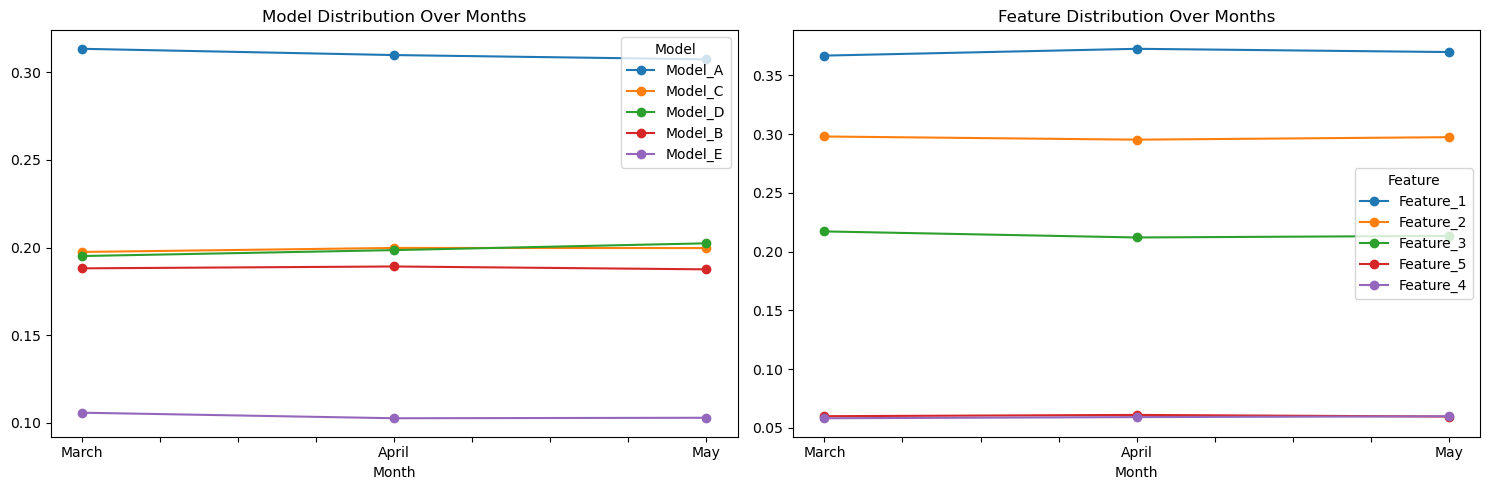

In [83]:
# Model and feature distribution (normalized) over 3 months
license_trends = pd.DataFrame()
model_trends = pd.DataFrame()
feature_trends = pd.DataFrame()
months = ['03', '04', '05']

for m in months:
    month_label = {'03': 'March', '04': 'April', '05': 'May'}[m]
    model_counts = df[df['month'] == m]['model'].value_counts(normalize=True)
    feature_counts = df[df['month'] == m]['feature'].value_counts(normalize=True)
    
    model_trends[month_label] = model_counts
    feature_trends[month_label] = feature_counts

model_trends = model_trends.T
feature_trends = feature_trends.T

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True)

# Model trends
model_trends.plot(ax=axes[0], marker='o')
axes[0].set_title('Model Distribution Over Months')
axes[0].set_xlabel('Month')
axes[0].legend(title='Model')

# Feature trends
feature_trends.plot(ax=axes[1], marker='o')
axes[1].set_title('Feature Distribution Over Months')
axes[1].set_xlabel('Month')
axes[1].legend(title='Feature')

plt.tight_layout()
plt.show()


*The distribution of **models** and **features** user activity over the months does not change significantly. The proportions stabilize from **March** to **May**, maintaining roughly the same percentages.*

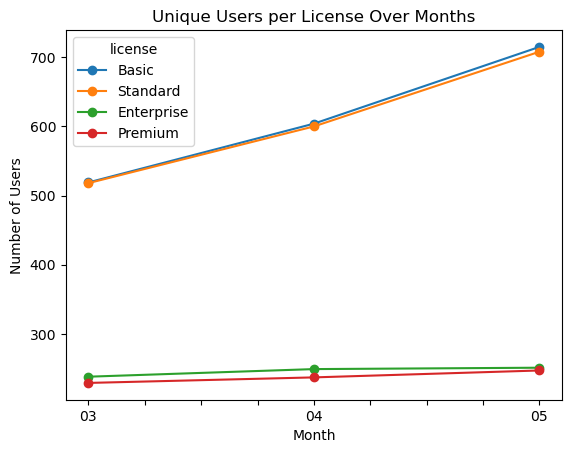

In [85]:
# How unique users per license change
license_counts_dict = {}

for m in months:
    df_month = df[df['month'] == m]
    df_unique = df_month.drop_duplicates(subset=['uuid', 'license'])
    license_counts = df_unique['license'].value_counts()
    license_counts_dict[m] = license_counts

license_counts_df = pd.DataFrame(license_counts_dict).fillna(0).astype(int)
license_counts_df.T.plot(marker='o')
plt.title('Unique Users per License Over Months')
plt.xlabel('Month')
plt.ylabel('Number of Users')
plt.show()

### General Conclusion 2

The percentages of **features** and **models** remain relatively stable across the months. However, the number of unique users with **Basic** and **Standard** licenses increased sharply in **April** and **May** (from roughly 500 to 700 users).  

Interestingly, across these three months, the number of users who **changed license type** remains low (approximately 3% of all unique users). 

*This raises the question: what drove the surge in Basic and Standard license users?*


## Part 3: New users rate, retention rate and underlying activities
In this part, new users rate, retention rate are analysed. Furthermore, what do new users use (license, model, feature) is of important interest?

In [54]:
query = """ 
WITH Mar_user AS (
SELECT DISTINCT uuid AS user_Mar
FROM df
WHERE month = '03'), Apr_uuid AS (
SELECT DISTINCT uuid AS user_Apr
FROM df
WHERE month = '04'
AND uuid NOT IN (SELECT * FROM Mar_user))

SELECT * FROM df
WHERE uuid IN (SELECT * FROM Apr_uuid)
AND month = '04';
"""

df_Apr_new_user = sqldf(query)

query = """ 
WITH MarApr_user AS (
SELECT DISTINCT uuid AS user_Mar
FROM df
WHERE strftime('%m', day_id) IN ('03','04')), May_user AS (
SELECT DISTINCT uuid AS user_May
FROM df
WHERE month = '05' AND uuid NOT IN (SELECT * FROM MarApr_user))

SELECT * FROM df
WHERE month = '05'
AND uuid IN (SELECT * FROM May_user);
"""

df_May_new_user = sqldf(query)

In [55]:
print(f'Total number of new users in April is: {len(df_Apr_new_user['uuid'].unique())} \n')
print(df_Apr_new_user.groupby('uuid')['license'].unique().value_counts())
print('\n')

print(f'Total number of new users in May is: {len(df_May_new_user['uuid'].unique())} \n')
print(df_May_new_user.groupby('uuid')['license'].unique().value_counts())

Total number of new users in April is: 185 

license
[Basic]         86
[Standard]      80
[Enterprise]    11
[Premium]        8
Name: count, dtype: int64


Total number of new users in May is: 226 

license
[Basic]         107
[Standard]      107
[Premium]        10
[Enterprise]      2
Name: count, dtype: int64


In total, the IDEs has **411** users across a couple of months.
**92%** of these new users opted for Basic and Standard license which explained the surge in Basic and Standard license in April and May.

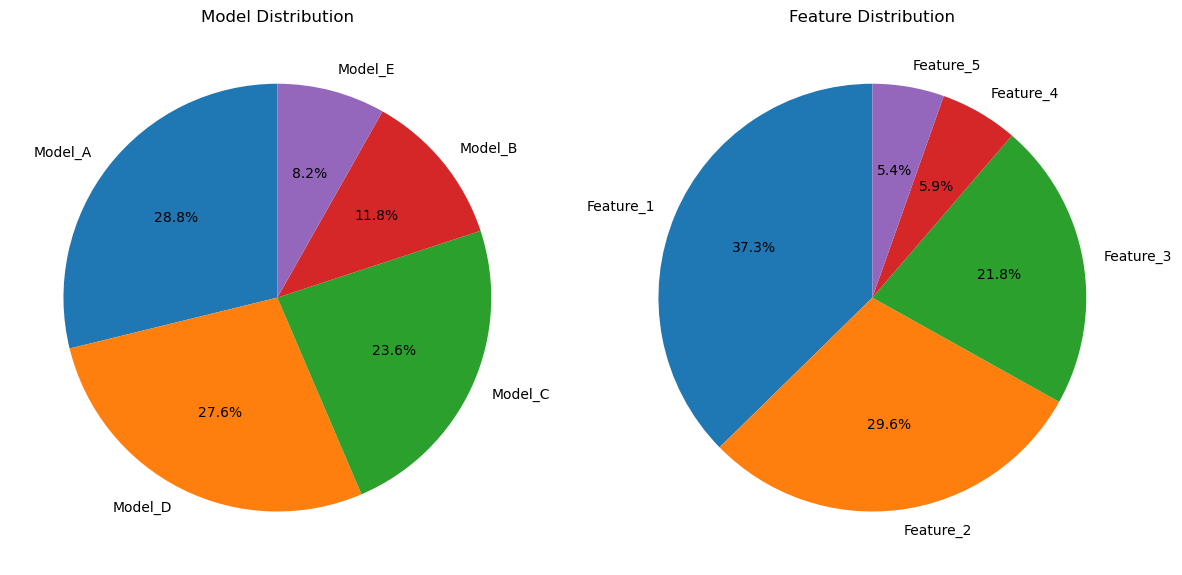

Normalized user usage of each type of model and feature in April and May 

model
Model_A    0.308418
Model_D    0.200664
Model_C    0.199746
Model_B    0.188328
Model_E    0.102845
Name: proportion, dtype: float64


feature
Feature_1    0.371182
Feature_2    0.296470
Feature_3    0.212765
Feature_5    0.060163
Feature_4    0.059421
Name: proportion, dtype: float64


In [64]:
# In April and May, what have those new users done?
df_new_users = pd.concat([df_Apr_new_user, df_May_new_user])

model_counts = df_new_users['model'].value_counts(normalize=True)
feature_counts = df_new_users['feature'].value_counts(normalize=True)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(12, 6))
axes[0].pie(model_counts, labels=model_counts.index, autopct='%1.1f%%', startangle=90)
axes[0].set_title('Model Distribution')
axes[1].pie(feature_counts, labels=feature_counts.index, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Feature Distribution')

plt.tight_layout()
plt.show()

print('Normalized user usage for each model and feature in April and May:\n')
print(df[df['month'].isin(['04','05'])]['model'].value_counts(normalize=True))
print('\n')
print(df[df['month'].isin(['04','05'])]['feature'].value_counts(normalize=True))

These pie charts show the choices of **new users** across the two months.  

We can see that **Model A** and **Feature 1** remain dominant, similar to the trends observed for all users during this period.  

However, there is a notable increase in the usage proportions of **Model D** and **Model C** among new users compared to the average activity of all users over these two months. While 40% of all users used Model D and Model C, this population of new users used these models **more than 50% of the time**, representing a surprising **10% rise**.  

At the same time, the proportion of **Model A** usage slightly decreased among new users, and **Model B** usage also decreased by **7%**.


In [68]:
query = """
with user_Apr as (SELECT DISTINCT uuid FROM df
WHERE month = '04')

SELECT COUNT(DISTINCT a.uuid)*1.0 / (SELECT COUNT(DISTINCT b.uuid) FROM df b WHERE b.month = '03') AS churn_rate_Apr FROM df a
WHERE a.month = '03' AND a.uuid NOT IN (SELECT uuid FROM user_Apr);
"""

df_March_churn = sqldf(query)

query = """
with user_May as (SELECT DISTINCT uuid FROM df
WHERE month = '05')

SELECT COUNT(DISTINCT a.uuid)*1.0 / (SELECT COUNT(DISTINCT b.uuid) FROM df b WHERE b.month = '04') AS churn_rate_May FROM df a
WHERE a.month = '04' AND a.uuid NOT IN (SELECT uuid FROM user_May);
"""
df_Apr_churn = sqldf(query)

print(df_March_churn, '\n')
print(df_Apr_churn)

   churn_rate_Apr
0        0.001375 

   churn_rate_May
0        0.001221


The **churn rate** is very low, indicating that fewer than **10 users** stopped using this IDE during this period.


### General Conclusion Part 3
Across April and May, **new users** continued to favor **Model A** and **Feature 1**, consistent with overall user trends. However, there was a notable shift among new users: the usage proportion of **Model D** and **Model C** increased by approximately **10%** compared to the average for all users, while **Model A** and **Model B** slightly decreased.  

At the same time, the **churn rate** remained very low, with fewer than **10 users** discontinuing use of this IDE during the period.  

Overall, this suggests that **new users largely follow existing usage patterns**, but show a greater preference shift toward Models D and C, while retention remains strong.

## Part 4: A closer look at unit cost and request count
In this part, we will have a closer look at `spent_amount` and `requests_cnt` variables to extract more insights regarding the relationship between these variables with other existing variables in the dataset.

Pearson correlation: 0.944, p-value: 0.000e+00

Median spent/request ratio per license:
license
Basic         0.246500
Enterprise    0.242381
Premium       0.242245
Standard      0.245000
dtype: float64


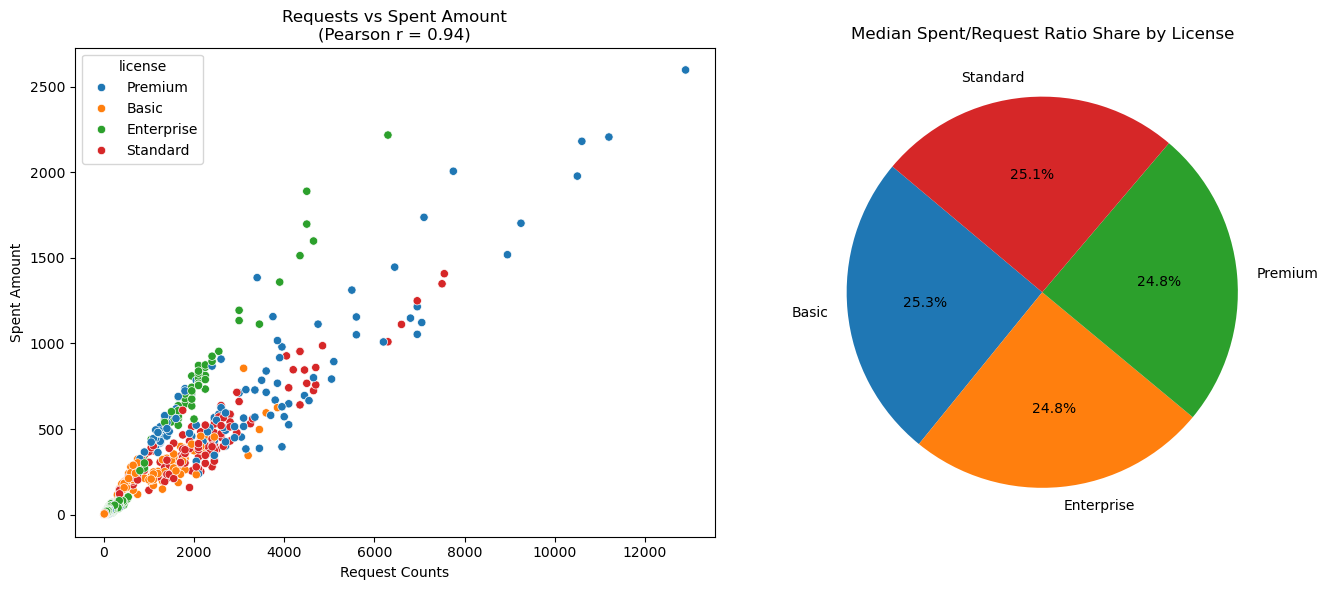

In [17]:
# Pearson's r test
corr, p_value = pearsonr(df['requests_cnt'], df['spent_amount'])
print(f"Pearson correlation: {corr:.3f}, p-value: {p_value:.3e}")

# Finding ratio of median spent amount and median request count 
median_ratio = (
    df.groupby('license')['spent_amount'].median() /
    df.groupby('license')['requests_cnt'].median())

print("\nMedian spent/request ratio per license:")
print(median_ratio)

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sns.scatterplot(
    data=df,
    x='requests_cnt',
    y='spent_amount',
    hue='license',
    ax=axes[0])

axes[0].set_title(f"Requests vs Spent Amount\n(Pearson r = {corr:.2f})")
axes[0].set_xlabel('Request Counts')
axes[0].set_ylabel('Spent Amount')

axes[1].pie(
    median_ratio,
    labels=median_ratio.index,
    autopct='%1.1f%%',
    startangle=140)

axes[1].set_title('Median Spent/Request Ratio Share by License')

plt.tight_layout()
plt.show()

The **Pearson correlation test** indicates a very strong positive correlation between **spent amount** and **request count** (**r = 0.944, p < 0.0001**).  

The scatterplot further illustrates this relationship: the more requests a user makes, the higher the total units spent. The points are colored by **user license type**. Most data points cluster in the **bottom-left region**, showing that the majority of users made between 0 and 4000 requests.  

Premium and enterprise users exhibit greater variability in both request count and spent amount, while users of other license types cluster more tightly. To reduce bias from extreme values, it is better to consider **median values** rather than means.  

When examining the **median spent-per-request ratio** by license, the values are essentially equal: all users, regardless of license type, spend approximately **0.245 units per request**.


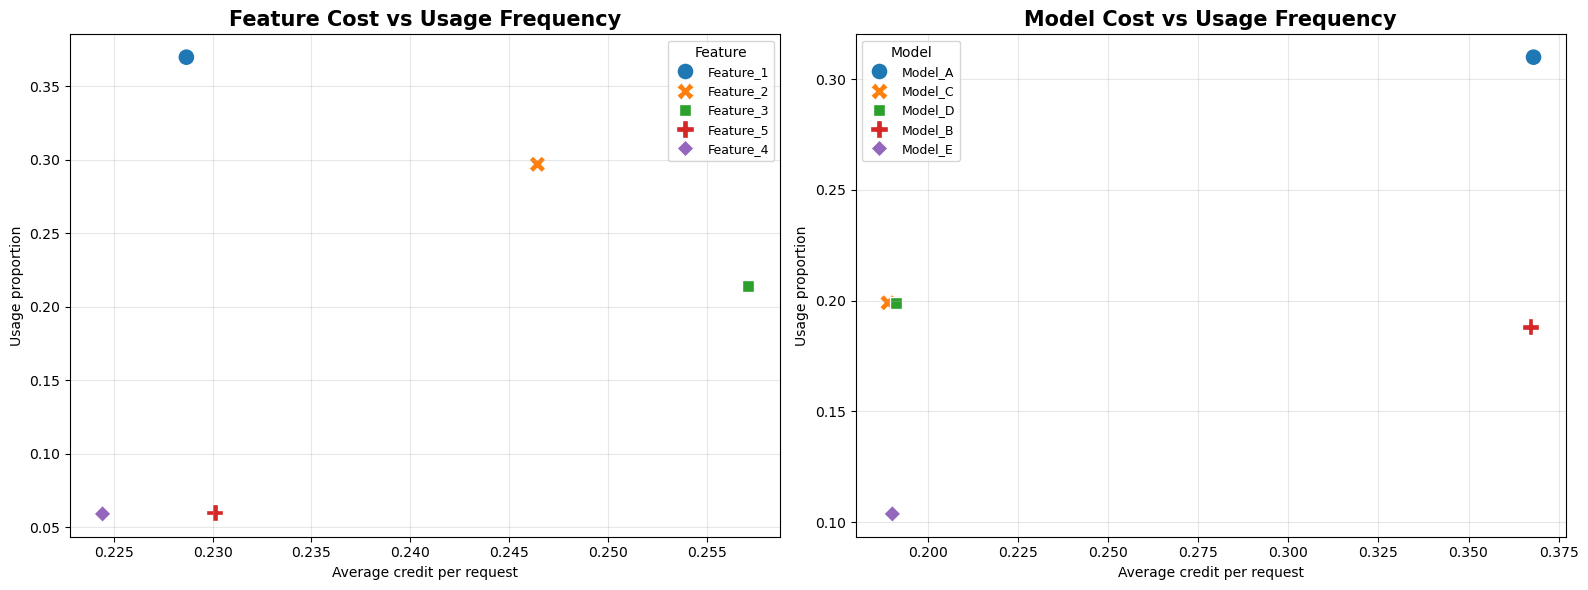

In [74]:
# Compare ratios with usage frequency for each model and feature type
x_feat = df.groupby('feature')['spent_amount'].sum() / df.groupby('feature')['requests_cnt'].sum()
y_feat = df['feature'].value_counts(normalize=True)
x_feat = x_feat[y_feat.index]

x_model = df.groupby('model')['spent_amount'].sum() / df.groupby('model')['requests_cnt'].sum()
y_model = df['model'].value_counts(normalize=True)
x_model = x_model[y_model.index]

df_feat_plot = pd.DataFrame({
    'Average credit per request': x_feat.values,
    'Usage proportion': y_feat.values,
    'Feature': x_feat.index})

df_model_plot = pd.DataFrame({
    'Average credit per request': x_model.values,
    'Usage proportion': y_model.values,
    'Model': x_model.index})

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(
    data=df_feat_plot,
    x='Average credit per request',
    y='Usage proportion',
    hue='Feature',
    style='Feature',
    s=150,
    ax=axes[0])

axes[0].set_title('Feature Cost vs Usage Frequency', fontsize=15, weight='bold')
axes[0].grid(alpha=0.3)
axes[0].legend(title='Feature', fontsize=9, title_fontsize=10, loc='best')

sns.scatterplot(
    data=df_model_plot,
    x='Average credit per request',
    y='Usage proportion',
    hue='Model',
    style='Model',
    s=150,
    ax=axes[1])

axes[1].set_title('Model Cost vs Usage Frequency', fontsize=15, weight='bold')
axes[1].grid(alpha=0.3)
axes[1].legend(title='Model', fontsize=9, title_fontsize=10, loc='best')

plt.tight_layout()
plt.show()


These two plots illustrate **feature usage** and **average amount spent per request**.  

The **range of the per-usage request ratio** across features is much smaller compared to models. For features, the **minimum** and **maximum** values are **0.224** and **0.257**, respectively.  

In contrast, the range for models is much larger, with a **minimum** of **0.18** and a **maximum** of **0.36**. This indicates that engagement intensity varies more widely between models than between features.

Regarding **feature cost vs. usage frequency**, Features 4 and 5 have low usage proportions (approximately 5%) and relatively low costs (around 0.225–0.23 units). The most efficient ratio appears in **Feature 1**, which has a similar cost to Features 4 and 5 but is used the most among all features (over 35%). **Feature 3** costs about 10% more than Feature 1 but is used 15% less frequently. **Feature 2** is used in roughly 30% of activity logs and has a moderate cost (~0.245 units). 


For **model cost vs. usage frequency**, an interesting pattern emerges. **Model A** is used in more than 30% of all user activities and has a high cost (0.375 units). **Models C and D** are used less frequently (around 20%) but are cheaper, costing only 0.20 units per request. **Model B** is used even less than Models A, C, and D, yet its cost per request is similar to Model A.  


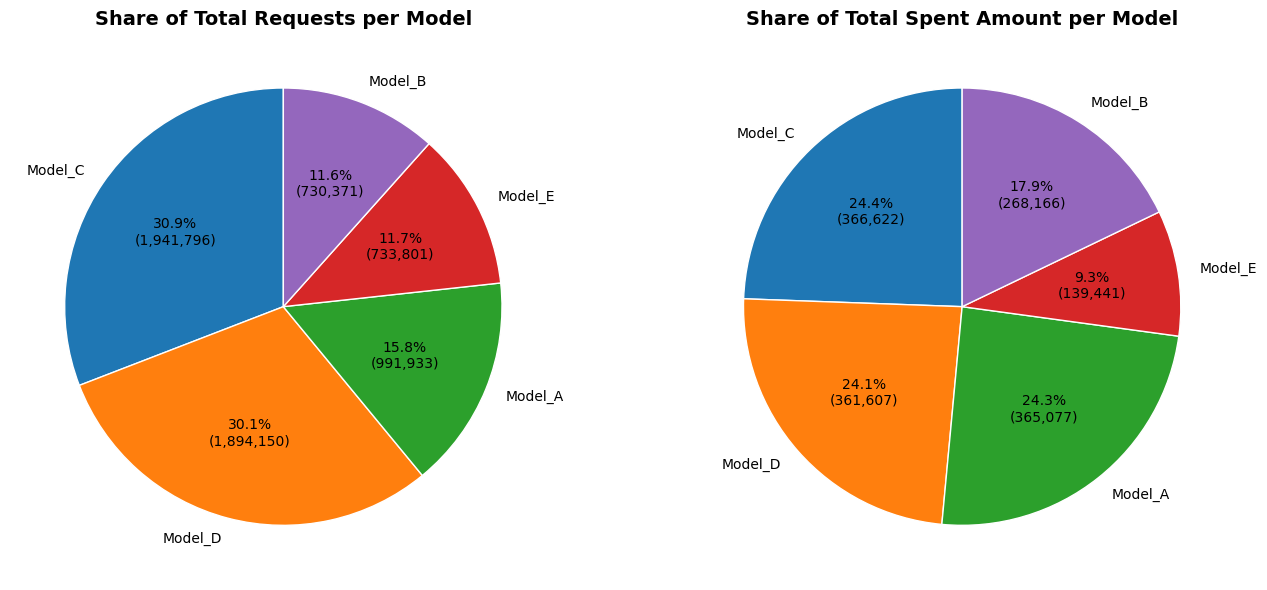

In [27]:
df_model_summary = (
    df.groupby('model')[['requests_cnt', 'spent_amount']]
      .sum()
      .sort_values(by=['requests_cnt', 'spent_amount'], ascending=False))

def make_autopct(values):
    def my_autopct(pct):
        total = sum(values)
        val = int(round(pct * total / 100.0))
        return f"{pct:.1f}%\n({val:,})"
    return my_autopct

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].pie(
    df_model_summary['requests_cnt'],
    labels=df_model_summary.index,
    autopct=make_autopct(df_model_summary['requests_cnt']),
    startangle=90,
    wedgeprops={'edgecolor': 'white'},
    textprops={'fontsize': 10})

axes[0].set_title('Share of Total Requests per Model', fontsize=14, weight='bold')

axes[1].pie(
    df_model_summary['spent_amount'],
    labels=df_model_summary.index,
    autopct=make_autopct(df_model_summary['spent_amount']),
    startangle=90,
    wedgeprops={'edgecolor': 'white'},
    textprops={'fontsize': 10})

axes[1].set_title('Share of Total Spent Amount per Model', fontsize=14, weight='bold')

plt.tight_layout()
plt.show()

### Observations on User Activity and Requests

So far, we have defined **user activity** as the number of **activity logs** (rows) in the dataset. If we instead define user activity by the **number of requests made**, the conclusions may differ.  

The **'Share of Total Requests per Model'** pie chart shows that nearly **2 million prompts** were made for **Model C**, making it the most used model in terms of request count. **Model D** follows with over **1.8 million prompts**. **Model A** has fewer than **1 million prompts**, ranking third.  

The **'Share of Total Spent Amount per Model'** pie chart shows a partially similar pattern, except **Model A** stands out with a very high total spent amount (24.3%). This aligns with the observation that **Model A is more expensive per request**, resulting in a high total spend despite fewer requests.  

These observations highlight a different perspective on classifying user activity. If we only consider **activity logs**, we might prematurely conclude that **Model A** is the most common and most used model. However, when considering **request counts**, **Models C and D** surpass Model A in actual usage.


In the following code blocks and explanations, **user activity** is broken down into two concepts:

- **User Reach**: the number of **unique users** using a given feature.  
- **Engagement Intensity**: the **number of requests** made for that feature.


In [31]:
query = """
WITH daily_stats AS (
    SELECT
        model,
        day_id,
        COUNT(DISTINCT uuid) AS daily_users,
        SUM(requests_cnt) AS daily_requests
    FROM df
    GROUP BY model, day_id
)
SELECT
    model,
    AVG(daily_users * 1.0) AS avg_user_reach_per_day,
    AVG(daily_requests * 1.0 / daily_users) AS avg_engagement_intensity_per_day
FROM daily_stats
GROUP BY model
ORDER BY avg_user_reach_per_day DESC;
"""

df_average_per_user_daily = sqldf(query)
print(df_average_per_user_daily)

     model  avg_user_reach_per_day  avg_engagement_intensity_per_day
0  Model_A              251.597826                         41.494353
1  Model_D              166.826087                        120.619191
2  Model_C              166.521739                        124.499969
3  Model_B              155.380435                         49.304896
4  Model_E               89.282609                         87.678202


The discrepancy is now apparent. While, on average, at least **251 users** use **Model A** daily, each user makes only **41.49 requests per day** for this model.  

In contrast, **Models D and C** each have an average daily user reach of at least **166**, and receive more than **120 requests per user per day**. **Model B** follows a similar pattern to Model A, with high daily user reach but significantly lower requests per user compared to Models D and C.  

Next, we will examine how **user reach** and **engagement intensity** fluctuate daily for each model over the three-month period.


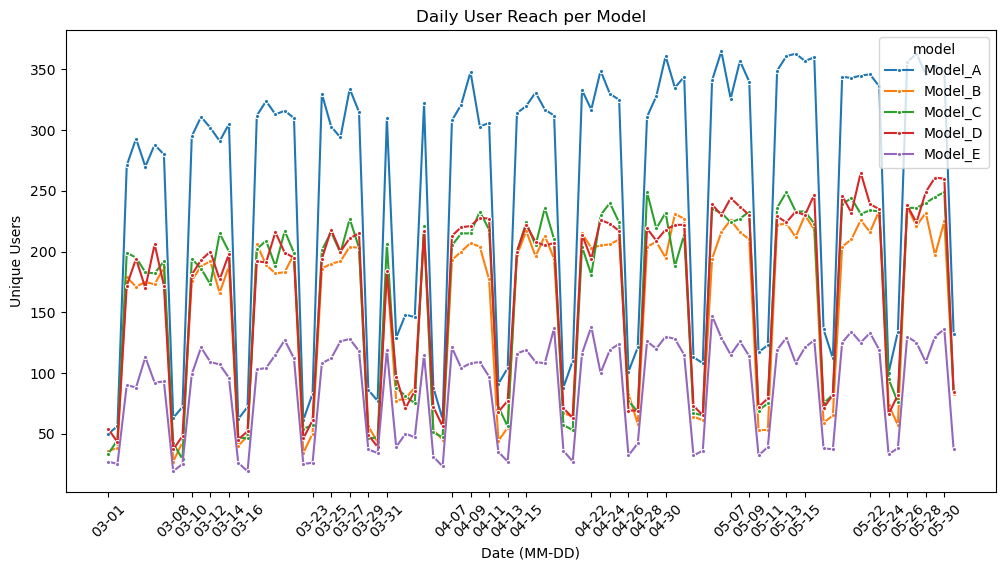

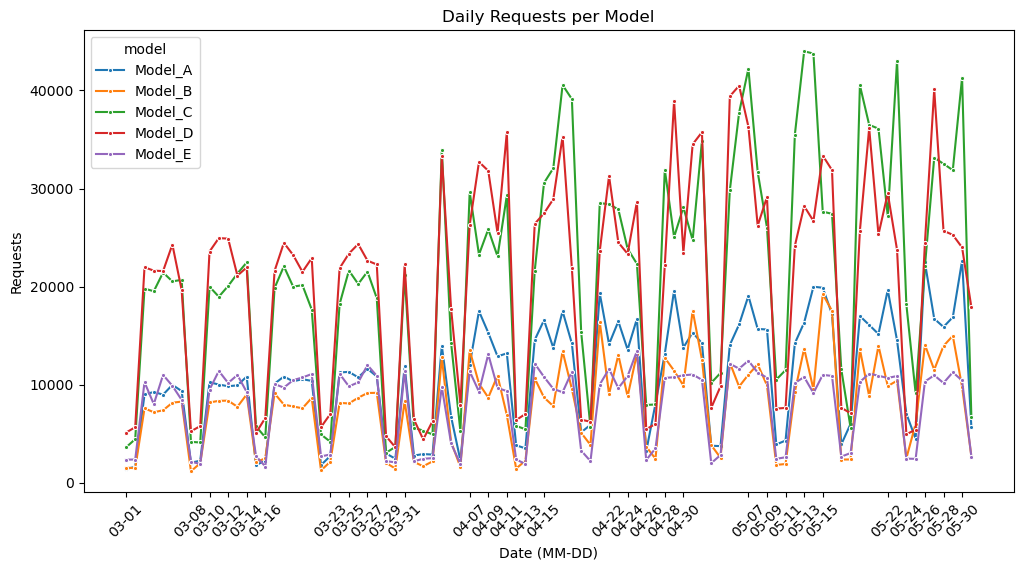

In [25]:
query = """
SELECT
    model,
    strftime('%m-%d', day_id) AS day_id,
    COUNT(DISTINCT uuid) AS daily_users,
    SUM(requests_cnt) AS daily_requests
FROM df
GROUP BY model, day_id
"""

df_daily = sqldf(query)

# Daily reach
plt.figure(figsize=(12,6))
sns.lineplot(data=df_daily, x='day_id', y='daily_users', hue='model', marker='.')
plt.title('Daily User Reach per Model')
plt.ylabel('Unique Users')
plt.xlabel('Date (MM-DD)')
xticks = df_daily['day_id'].iloc[::15]
plt.xticks(xticks, rotation=45)
plt.show()

# Daily requests
plt.figure(figsize=(12,6))
sns.lineplot(data=df_daily, x='day_id', y='daily_requests', hue='model', marker='.')
plt.title('Daily Requests per Model')
plt.ylabel('Requests')
plt.xlabel('Date (MM-DD)')
xticks = df_daily['day_id'].iloc[::15]
plt.xticks(xticks, rotation=45)
plt.show()

An interesting observation from these time series analyses is that users are less active on weekends, with most peaks in activity occurring during weekdays.  

The **user reach** of **Model A** is extremely high across the three months, consistently about **double** that of the other models. However, the **number of requests** for Model A was only around **10,000 per day** in May, while Models C and D had roughly **20,000 requests per day**, doubling Model A’s daily requests.  

This discrepancy is consistent throughout the period: Model A is widely reached but not requested as frequently as Models C and D.  

Additionally, there is a clear **upward trend over time**. More users are engaging with these models in May compared to previous months, with daily requests showing an even more pronounced increase. At certain points in May, **Model C** reached a peak of **40,000 requests in a single day**, the highest recorded for any model in this period. By observing the plots, it is evident that overall requests across all models were higher in **April and May** compared to **March**.


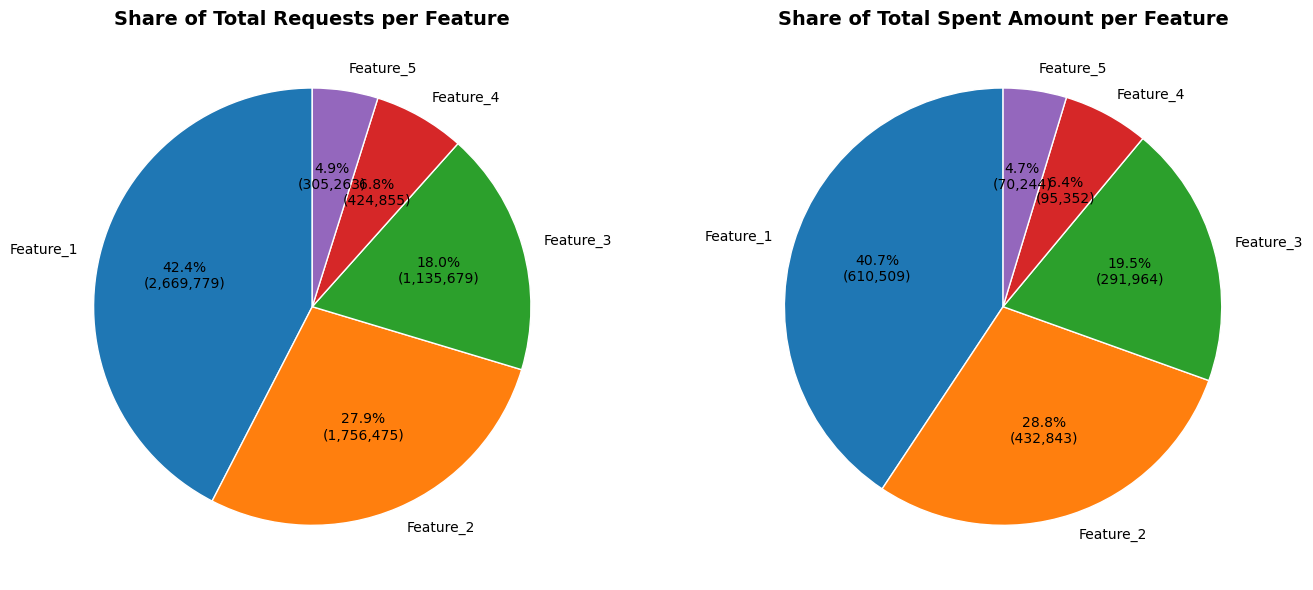

In [28]:
df_feature_summary = (
    df.groupby('feature')[['requests_cnt', 'spent_amount']]
      .sum()
      .sort_values(by=['requests_cnt', 'spent_amount'], ascending=False))
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Plotting
axes[0].pie(
    df_feature_summary['requests_cnt'],
    labels=df_feature_summary.index,
    autopct=make_autopct(df_feature_summary['requests_cnt']),
    startangle=90,
    wedgeprops={'edgecolor': 'white'},
    textprops={'fontsize': 10})
axes[0].set_title('Share of Total Requests per Feature', fontsize=14, weight='bold')

axes[1].pie(
    df_feature_summary['spent_amount'],
    labels=df_feature_summary.index,
    autopct=make_autopct(df_feature_summary['spent_amount']),
    startangle=90,
    wedgeprops={'edgecolor': 'white'},
    textprops={'fontsize': 10})
axes[1].set_title('Share of Total Spent Amount per Feature', fontsize=14, weight='bold')

plt.tight_layout()
plt.show()

These two pie charts demonstrate a **consistent ranking** of features in terms of both **request counts** and **total spent amounts**.  

This finding aligns with our observations in Part 1: **Feature 1** is used much more frequently by users. Here, it is also requested the most, followed by **Features 2, 3, 4, and 5**. Importantly, the pie chart of **total spent amount per feature** shows the same ranking.  

This indicates that the **units spent per request** for these features are fairly consistent, so the total requests per feature closely resemble the total spent amount per feature. This also confirms our earlier observation that the **per-usage spent amount for features is less variable** than for models, which exhibit a larger range.


In [86]:
query_feature = """
WITH daily_stats AS (
    SELECT
        feature,
        day_id,
        COUNT(DISTINCT uuid) AS daily_users,
        SUM(requests_cnt) AS daily_requests
    FROM df
    GROUP BY feature, day_id
)
SELECT
    feature,
    AVG(daily_users * 1.0) AS avg_user_reach_per_day,
    AVG(daily_requests * 1.0 / daily_users) AS avg_engagement_intensity_per_day
FROM daily_stats
GROUP BY feature
ORDER BY avg_user_reach_per_day DESC;
"""

df_average_per_user_daily_feature = sqldf(query_feature)
print(df_average_per_user_daily_feature)

     feature  avg_user_reach_per_day  avg_engagement_intensity_per_day
0  Feature_1              461.445652                         61.254181
1  Feature_2              377.434783                         50.737445
2  Feature_3              276.173913                         44.632074
3  Feature_5               79.576087                         41.824461
4  Feature_4               78.043478                         58.292187


This table also highlights how **features are far more consistent** in terms of user activity compared to models.  
**Feature 1** attracts the highest number of users per day and also receives the most requests per user per day.  

The overall **ranking remains stable** — Feature 1 is followed by Features 2, 3, 4, and 5 — suggesting a strong positive relationship between how many users engage with a feature and how intensively they use it (measured by requests made).  

An interesting exception is **Feature 4**, which, despite having a relatively small user base (only **78 users per day** on average), shows **a high engagement intensity** of nearly **58 requests per user per day**. This implies that although few users utilize Feature 4, those who do tend to be **heavy or power users**, generating a disproportionately high number of requests.


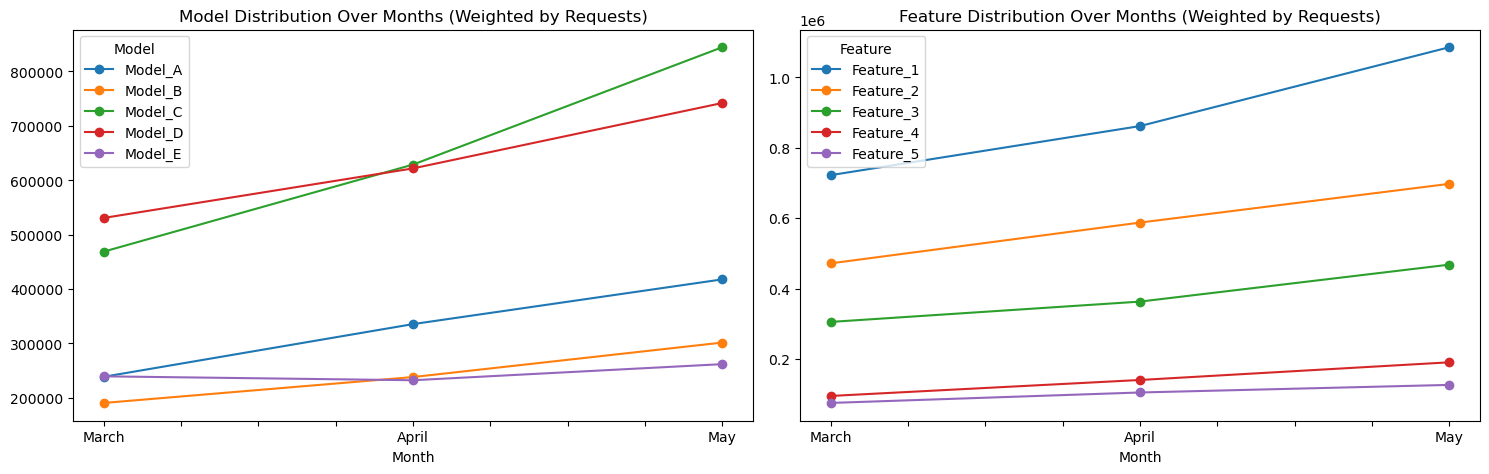

In [36]:
license_trends = pd.DataFrame()
model_trends = pd.DataFrame()
feature_trends = pd.DataFrame()

for m in months:
    month_label = {'03': 'March', '04': 'April', '05': 'May'}[m]
    model_counts = df[df['month'] == m].groupby('model')['requests_cnt'].sum()
    feature_counts = df[df['month'] == m].groupby('feature')['requests_cnt'].sum()
    
    model_trends[month_label] = model_counts
    feature_trends[month_label] = feature_counts

model_trends = model_trends.T
feature_trends = feature_trends.T

# Plotting
fig, axes = plt.subplots(1, 2, figsize=(15, 5), sharex=True)

# Model
model_trends.plot(ax=axes[0], marker='o')
axes[0].set_title('Model Distribution Over Months (Weighted by Requests)')
axes[0].set_xlabel('Month')
axes[0].legend(title='Model')

# Feature
feature_trends.plot(ax=axes[1], marker='o')
axes[1].set_title('Feature Distribution Over Months (Weighted by Requests)')
axes[1].set_xlabel('Month')
axes[1].legend(title='Feature')

plt.tight_layout()
plt.show()


**Overall**, the number of requests made for all **models** and **features** increased sharply over the three-month period.  
**Model C**, which had fewer requests than **Model D** in March, **surpassed it by May** with over **800,000 requests** made.


In [107]:
# Top 3 models byy requests per license
print("=== Top 3 Models by Requests per License ===\n")
top_models = (
    df.groupby(['license', 'model'])['requests_cnt']
      .sum()
      .reset_index()
      .sort_values(['license', 'requests_cnt'], ascending=[True, False])
      .groupby('license')
      .head(3)
)
print(top_models)

# Top 3 features by requests per license
print("\n=== Top 3 Features by Requests per License ===\n")
top_features = (
    df.groupby(['license', 'feature'])['requests_cnt']
      .sum()
      .reset_index()
      .sort_values(['license', 'requests_cnt'], ascending=[True, False])
      .groupby('license')
      .head(3)
)
print(top_features)

=== Top 3 Models by Requests per License ===

       license    model  requests_cnt
2        Basic  Model_C      366564.0
3        Basic  Model_D      333519.0
0        Basic  Model_A      181463.0
8   Enterprise  Model_D      548537.0
7   Enterprise  Model_C      498204.0
5   Enterprise  Model_A      309526.0
12     Premium  Model_C      676182.0
13     Premium  Model_D      406016.0
10     Premium  Model_A      258014.0
18    Standard  Model_D      606078.0
17    Standard  Model_C      400846.0
15    Standard  Model_A      242930.0

=== Top 3 Features by Requests per License ===

       license    feature  requests_cnt
0        Basic  Feature_1      466585.0
1        Basic  Feature_2      290871.0
2        Basic  Feature_3      196885.0
5   Enterprise  Feature_1      804744.0
6   Enterprise  Feature_2      551073.0
7   Enterprise  Feature_3      354036.0
10     Premium  Feature_1      730810.0
11     Premium  Feature_2      473730.0
12     Premium  Feature_3      311785.0
15    Stand

#### Users' Preferences of Features and Models:

Across all license types, **Feature 1** is the most requested, followed by **Feature 2** and **Feature 3** — a consistent pattern regardless of license tier.  

When it comes to **model preferences**, **Basic** and **Premium** users tend to request **Model C** more frequently than **Model D**, whereas **Enterprise** and **Standard** users show the opposite trend.  
This distinction suggests potential for **tailored marketing strategies** based on license type and usage preference.

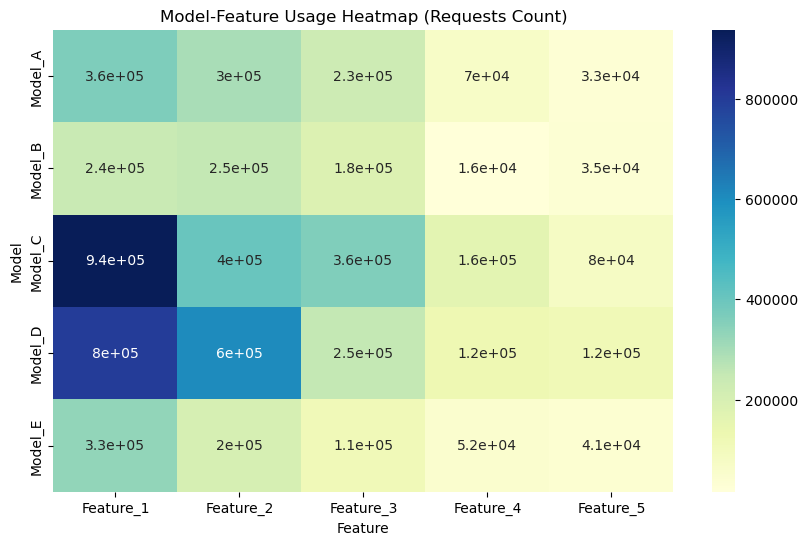

In [58]:
# Group by model and feature, sum requests
df_grouped = df.groupby(['model', 'feature'])['requests_cnt'].sum().unstack(fill_value=0)

# Plotting
plt.figure(figsize=(10,6))
sns.heatmap(df_grouped, annot=True, cmap='YlGnBu')
plt.title('Model-Feature Usage Heatmap (Requests Count)')
plt.xlabel('Feature')
plt.ylabel('Model')
plt.show()

This heatmap reinforces previous findings — users most frequently request **Model C**, **Model D**, **Feature 1**, and **Feature 2**.


### General Conclusion Part 4

Part 4 provided a deeper understanding of how **request count** and **spending behavior** interact with other factors such as **model**, **feature**, and **license type**.

Overall, there is a **very strong positive correlation** between total spent amount and number of requests (r = 0.944, p < 0.0001), confirming that increased usage directly drives higher spending. However, this relationship varies substantially across models and features.  

For **models**, spending per request differs widely, from **0.18 to 0.36 units**, showing that some models (notably **Model A**) are considerably more expensive to use. In contrast, **features** are much more stable, with spending per request ranging only from **0.224 to 0.257 units**, reflecting a more consistent cost-to-usage relationship.  

Over time, user engagement intensified dramatically. Total requests for all models and features **skyrocketed between March and May**, with **Model C** overtaking **Model D** as the most requested model by May (over **800,000 requests**). This was accompanied by a clear upward trend in both **user reach** and **engagement intensity**, particularly in April and May, while user activity dipped during weekends.

Feature usage remained highly consistent throughout: **Feature 1** was dominant in both total requests and spending, followed by **Features 2 and 3**. Interestingly, **Feature 4** stood out for its smaller but more dedicated user base — few users accessed it, but those who did made a large number of requests, suggesting it attracts heavy or specialized users.

Finally, license-based analyses revealed distinct usage preferences. **Basic** and **Premium** users favored **Model C**, while **Enterprise** and **Standard** users leaned toward **Model D**. This insight presents opportunities for **targeted marketing strategies** and **product optimization** based on user segment behavior.

In essence, **Part 4 underscores how user engagement, spending patterns, and cost structures differ across models, features, and license types**, and highlights the importance of distinguishing between *activity frequency* and *request intensity* when analyzing user behavior.


## Recommendations

- **Personalized Default Model:**  
  Optimize user experience by automatically assigning a default model based on the user’s license type — **Model C** for *Basic* and *Premium* users, and **Model D** for *Standard* and *Enterprise* users. This ensures that users immediately access the model most aligned with their expected usage patterns and needs, reducing friction and improving satisfaction. The system should dynamically update defaults if the user’s license changes, preventing misalignment between license benefits and model availability.  
  *How* Integrate with onboarding workflows and account settings, show the default model to users with an option for manual override.

- **Spending-Aware Prompts:**  
  Introduce contextual, real-time recommendations when users select high-cost models for relatively simple tasks. For example, if a user chooses **Model A** for a task easily handled by **Model C**, display a prompt like:  
  > “Switch to Model C to save credits.”  
  This helps users make cost-efficient decisions, reduces credit waste, and encourages broader adoption of mid-tier models.  
  *Implementation considerations:* Use AI-based task analysis or historical usage patterns to suggest the most cost-effective option without limiting user choice.

- **Usage and Cost Visibility Tools:**  
  Implement a **usage meter** that tracks spending and provides visual feedback, sending alerts at critical thresholds (e.g., 50%, 75%). Allow users to set **optional spending caps**, such as restricting **Model A** usage to 30% of their monthly budget.  
  *Why:* Enhances transparency, prevents unexpected overages, and empowers users to proactively manage costs.  
  *How:* Integrate with dashboards, mobile notifications, and exportable reports for better visibility.

- **Loyalty and Retention Incentives:**  
  Leverage strong retention rates by introducing **loyalty tiers or rewards programs**, e.g., bonus credits, exclusive feature unlocks, or early access to new models.  
  *Why:* Strengthens user loyalty, encourages advocacy, and creates upselling opportunities.  
  *How* Tie rewards to usage milestones, subscription duration, or referral activity to create multiple retention pathways.

- **Model B Repricing:**  
  **Model B** is underutilized despite its high per-request cost. Consider a **price reduction (−15% to −30%)** or enhancing its value proposition (e.g., bundling with premium features).  
  *Why:* Increases adoption, improves perceived value, and aligns pricing with demand.  
  *How:* Conduct market analysis and A/B testing to identify the optimal pricing adjustment without reducing revenue.

- **Model A: High Reach, Low Engagement Intensity**  
  Users are aware of Model A and may test it occasionally. However, they rarely select it for actual tasks, possibly due to perceived cost, complexity, or misunderstanding of its advantages over Models C and D. To address this, clearly communicate the unique strengths of each model rather than simply presenting a list of options. This helps users understand which model to choose for specific features or tasks.  

  *Why:* Increase Model A engagement and adoption.  
  *How:* Highlight the value of Model A (e.g., accuracy, depth, speed), and incentivize experimentation with bonus credits or trial usage.